# Лабораторная работа: семантическая сегментация поражений листа/плода клубники

**Данные:** набор [Strawberry Disease Detection Dataset](https://www.kaggle.com/datasets/usmanafzaal/strawberry-disease-detection-dataset) загружается через `kagglehub` (см. раздел 1).

## 1. Выбор начальных условий и метрик качества

### Набор данных

Выбран датасет **Strawberry Disease Detection Dataset**. Это **практическая агрономическая задача**: ранняя диагностика болезней клубники по визуальным признакам. Исходные аннотации ориентированы на **сегментацию поражений** (контуры/маски областей симптомов). Для выполнения требований задания ТЗ **объединим все экземпляры одного класса болезни в один семантический класс на пиксельной маске** (не разделяем отдельные «острова» одной болезни как разные ID объектов). Фон и здоровая ткань выделяются отдельными классами.


### Метрики качества и обоснование

Для семантической сегментации используем:

1. **mIoU (mean Intersection-over-Union)** — стандарт для сегментации; устойчиво сравнивает перекрытие предсказанной и истинной областей класса, особенно при несбалансированных площадях классов.
2. **Mean Dice (F1 на уровне класса по маскам)** — хорошо коррелирует с «полезностью» маски при медицинской/биологической интерпретации (площадные поражения).
3. **Pixel Accuracy** — простая интерпретируемая величина, но может быть завышена при доминировании фона; поэтому **основной отчётной метрикой** считаем **mIoU**, а pixel accuracy — вспомогательной.

Ниже задаём единые функции метрик и общий цикл обучения/валидации.

In [5]:
import os
import json
import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import torch.nn.functional as F
from PIL import Image, ImageDraw
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import segmentation_models_pytorch as smp
from tqdm.auto import tqdm

import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import segmentation_models_pytorch as smp
from tqdm import tqdm

print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


True Tesla T4


In [6]:
import kagglehub

path = kagglehub.dataset_download("usmanafzaal/strawberry-disease-detection-dataset")
print("Path to dataset files:", path)

100%|██████████| 534M/534M [00:03<00:00, 146MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/usmanafzaal/strawberry-disease-detection-dataset/versions/1


### Загрузка данных и их анализ

В данном датасете представлено попарное соответствие файлов, а именно - .jpg + .json форматы. Это значит, что каждому изображению соответсвтует json-файл с аннотацией (координаты полигонов). Проверим валидность пар

In [7]:
DATA_ROOT = Path(path)

# Путь к папке train
train_dir = DATA_ROOT / "train"

# Собираем все jpg файлы
image_files = sorted([f for f in train_dir.glob("*.jpg")])
print(f"Найдено изображений: {len(image_files)}")

# Проверяем, что к каждому jpg есть json с таким же именем
valid_pairs = []
for img_path in image_files:
    json_path = train_dir / f"{img_path.stem}.json"
    if json_path.exists():
        valid_pairs.append((img_path, json_path))
    else:
        print(f"Нет аннотации для {img_path.name}")

print(f"Валидных пар изображение + аннотация: {len(valid_pairs)}")

Найдено изображений: 1450
Валидных пар изображение + аннотация: 1450


### Определение классов и маппинг

Выделим все классы в датасете, проверим на соответствие размеров изображения в .jpg формате и в его json-аннотации. Создадим маппинг классов


In [8]:
# Функция для извлечения всех уникальных классов из json
def extract_classes_from_json(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)

    classes = set()
    for shape in data['shapes']:
        classes.add(shape['label'])
    return classes

# Собираем все уникальные метки из датасета
all_labels = set()
for img_path, json_path in valid_pairs:
    all_labels.update(extract_classes_from_json(json_path))

print("Найденные классы в датасете:")
for label in sorted(all_labels):
    print(f"   - {label}")

def verify_pair(img_path, json_path):
    # Загружаем JSON
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Получаем размеры из JSON
    json_h = data.get('imageHeight')
    json_w = data.get('imageWidth')

    # Получаем реальные размеры изображения
    img = cv2.imread(str(img_path))
    img_h, img_w = img.shape[:2]

    if json_h != img_h or json_w != img_w:
        print(f"Несоответствие размеров в {img_path.name}:")
        print(f"JSON: {json_w}x{json_h}, Изображение: {img_w}x{img_h}")
        return False
    return True

sorted_labels = sorted(all_labels)
class_mapping = {'background': 0}
for idx, label in enumerate(sorted_labels, start=1):
    class_mapping[label] = idx

print("\nПолучившийся маппинг:")
for label, idx in class_mapping.items():
    print(f"   {label} = {idx}")

num_classes = len(class_mapping)
print(f"\nКоличество классов: {num_classes}")

Найденные классы в датасете:
   - Angular Leafspot
   - Anthracnose Fruit Rot
   - Blossom Blight
   - Gray Mold
   - Leaf Spot
   - Powdery Mildew Fruit
   - Powdery Mildew Leaf

Получившийся маппинг:
   background = 0
   Angular Leafspot = 1
   Anthracnose Fruit Rot = 2
   Blossom Blight = 3
   Gray Mold = 4
   Leaf Spot = 5
   Powdery Mildew Fruit = 6
   Powdery Mildew Leaf = 7

Количество классов: 8


### Загрузчик данных

Пользовательский класс Dataset для PyTorch, который преобразует сырые пары изображений и JSON-аннотаций в формат, пригодный для обучения моделей семантической сегментации. При загрузке элемента изображение считывается через OpenCV и нормализуется, а JSON-аннотация конвертируется в попиксельную маску.

После применения опциональных аугментаций изображение преобразуется в тензор размерности каналы-высота-ширина со значениями от 0 до 1, а маска становится целочисленным тензором для вычисления функции потерь.

Размер датасета: 1450
Форма изображения: torch.Size([3, 256, 256])
Форма маски: torch.Size([256, 256])
Уникальные классы в маске: tensor([0, 1])


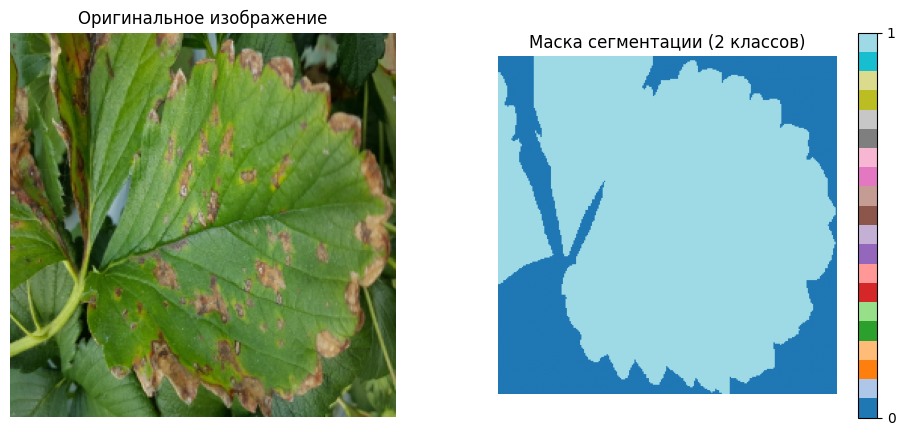


Разделение данных:
Обучающая выборка: 1160
Валидационная выборка: 290


In [9]:
class StrawberryDataset(Dataset):
    def __init__(self, pairs, class_mapping, image_size=256, transform=None):
        self.pairs = pairs
        self.class_mapping = class_mapping
        self.image_size = image_size
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, json_path = self.pairs[idx]

        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = self.json_to_mask(json_path, image.shape[:2])

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # resize к размеру, кратному 16
        image = cv2.resize(image, (self.image_size, self.image_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)

        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).long()

        return image, mask

    def json_to_mask(self, json_path, img_shape):
        with open(json_path, "r") as f:
            data = json.load(f)

        mask = np.zeros(img_shape[:2], dtype=np.uint8)

        for shape in data["shapes"]:
            label = shape["label"]
            if label not in self.class_mapping:
                continue

            class_id = self.class_mapping[label]
            points = np.array(shape["points"], dtype=np.int32)
            cv2.fillPoly(mask, [points], class_id)

        return mask



# Создаем датасет
dataset = StrawberryDataset(valid_pairs, class_mapping)

# Проверяем, что все работает
print(f"Размер датасета: {len(dataset)}")

# Загружаем один пример для проверки
image, mask = dataset[0]
print(f"Форма изображения: {image.shape}")  # Ожидаем (C, H, W)
print(f"Форма маски: {mask.shape}")         # Ожидаем (H, W)
print(f"Уникальные классы в маске: {torch.unique(mask)}")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Изображение (меняем порядок каналов обратно для отображения)
axes[0].imshow(image.permute(1, 2, 0).numpy())
axes[0].set_title("Оригинальное изображение")
axes[0].axis('off')

# Маска
im = axes[1].imshow(mask.numpy(), cmap='tab20')
axes[1].set_title(f"Маска сегментации ({len(torch.unique(mask))} классов)")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], ticks=range(num_classes))

plt.show()

train_pairs, val_pairs = train_test_split(
    valid_pairs,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"\nРазделение данных:")
print(f"Обучающая выборка: {len(train_pairs)}")
print(f"Валидационная выборка: {len(val_pairs)}")

IMAGE_SIZE = 256

train_dataset = StrawberryDataset(train_pairs, class_mapping, image_size=IMAGE_SIZE)
val_dataset = StrawberryDataset(val_pairs, class_mapping, image_size=IMAGE_SIZE)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)


### Обучение моделей



In [10]:
#!pip install -q segmentation-models-pytorch albumentations tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Текущее устройство:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


@torch.no_grad()
def update_confusion_matrix(confmat, preds, targets, num_classes):
    preds = preds.view(-1)
    targets = targets.view(-1)

    valid_mask = (targets >= 0) & (targets < num_classes)
    preds = preds[valid_mask]
    targets = targets[valid_mask]

    inds = num_classes * targets + preds
    confmat += torch.bincount(inds, minlength=num_classes ** 2).reshape(num_classes, num_classes)
    return confmat


@torch.no_grad()
def compute_metrics_from_confmat(confmat):
    confmat = confmat.float()

    tp = torch.diag(confmat)
    fp = confmat.sum(dim=0) - tp
    fn = confmat.sum(dim=1) - tp

    iou = tp / (tp + fp + fn + 1e-7)
    dice = 2 * tp / (2 * tp + fp + fn + 1e-7)
    pixel_acc = tp.sum() / (confmat.sum() + 1e-7)

    valid_iou = ~torch.isnan(iou)
    valid_dice = ~torch.isnan(dice)

    miou = iou[valid_iou].mean().item() if valid_iou.any() else 0.0
    mdice = dice[valid_dice].mean().item() if valid_dice.any() else 0.0

    return {
        "mIoU": miou,
        "mDice": mdice,
        "Pixel Accuracy": pixel_acc.item()
    }


def get_logits(outputs):
    if isinstance(outputs, dict):
        return outputs["out"]
    return outputs


def train_epoch(model, train_loader, criterion, optimizer, device, scaler=None):
    model.train()
    running_loss = 0.0
    use_amp = scaler is not None and device.type == "cuda"

    for images, masks in tqdm(train_loader, desc="Training", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                logits = get_logits(outputs)
                loss = criterion(logits, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            logits = get_logits(outputs)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    return epoch_loss


@torch.no_grad()
def validate(model, val_loader, criterion, device, num_classes):
    model.eval()
    running_loss = 0.0
    confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64, device=device)

    for images, masks in tqdm(val_loader, desc="Validation", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        outputs = model(images)
        logits = get_logits(outputs)
        loss = criterion(logits, masks)

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)
        update_confusion_matrix(confmat, preds, masks, num_classes)

    val_loss = running_loss / len(val_loader.dataset)
    metrics = compute_metrics_from_confmat(confmat)

    return val_loss, metrics


def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    num_classes,
    device,
    epochs=10,
    lr=3e-4,
    save_dir="checkpoints"
):
    os.makedirs(save_dir, exist_ok=True)

    print(f"Обучение модели: {model_name}...")


    ce_loss = nn.CrossEntropyLoss()
    dice_loss = smp.losses.DiceLoss(mode="multiclass", from_logits=True)

    def combined_loss(pred, target):
        return 0.7 * ce_loss(pred, target) + 0.3 * dice_loss(pred, target)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=2,
        factor=0.5
    )

    scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_mIoU": [],
        "val_mDice": [],
        "val_acc": []
    }

    best_miou = -1.0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")

        train_loss = train_epoch(
            model=model,
            train_loader=train_loader,
            criterion=combined_loss,
            optimizer=optimizer,
            device=device,
            scaler=scaler
        )

        val_loss, metrics = validate(
            model=model,
            val_loader=val_loader,
            criterion=combined_loss,
            device=device,
            num_classes=num_classes
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mIoU"].append(metrics["mIoU"])
        history["val_mDice"].append(metrics["mDice"])
        history["val_acc"].append(metrics["Pixel Accuracy"])

        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss:   {val_loss:.4f}")
        print(f"  Val mIoU:   {metrics['mIoU']:.4f}")
        print(f"  Val Dice:   {metrics['mDice']:.4f}")
        print(f"  Val Acc:    {metrics['Pixel Accuracy']:.4f}")

        if metrics["mIoU"] > best_miou:
            best_miou = metrics["mIoU"]
            save_path = os.path.join(save_dir, f"best_{model_name}.pth")
            torch.save(model.state_dict(), save_path)
            print(f"Новая лучшая модель! mIoU = {best_miou:.4f}")

    return history


num_classes = len(class_mapping)
print(f"Количество классов для сегментации: {num_classes}")
print("\nИНИЦИАЛИЗАЦИЯ МОДЕЛЕЙ")

# 1. CNN-модель
unet_model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=num_classes,
    activation=None
).to(device)

print(f"U-Net (CNN): {sum(p.numel() for p in unet_model.parameters()):,} параметров")

# 2. Transformer-based модель
transformer_model = smp.DeepLabV3Plus(
    encoder_name="mit_b0",
    encoder_weights="imagenet",
    in_channels=3,
    classes=num_classes,
    activation=None
).to(device)

print(f"DeepLabV3+ + MiT-B0 (Transformer): {sum(p.numel() for p in transformer_model.parameters()):,} параметров")


unet_history = train_model(
    model=unet_model,
    model_name="UNet",
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes,
    device=device,
    epochs=10,
    lr=3e-4
)

transformer_history = train_model(
    model=transformer_model,
    model_name="DeepLabV3Plus_MiTB0",
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes,
    device=device,
    epochs=10,
    lr=3e-4
)


Текущее устройство: cuda
GPU: Tesla T4
Количество классов для сегментации: 8

ИНИЦИАЛИЗАЦИЯ МОДЕЛЕЙ


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

U-Net (CNN): 14,329,224 параметров


...

  Train Loss: 0.2303
  Val Loss:   0.2075
  Val mIoU:   0.6281
  Val Dice:   0.7250
  Val Acc:    0.9167
Новая лучшая модель! mIoU = 0.6281

Epoch 7/10


  Train Loss: 0.2235
  Val Loss:   0.2073
  Val mIoU:   0.6703
  Val Dice:   0.7900
  Val Acc:    0.9134
Новая лучшая модель! mIoU = 0.6703

Epoch 8/10


  Train Loss: 0.1949
  Val Loss:   0.1796
  Val mIoU:   0.7099
  Val Dice:   0.8222
  Val Acc:    0.9272
Новая лучшая модель! mIoU = 0.7099

Epoch 9/10


  Train Loss: 0.1629
  Val Loss:   0.1691
  Val mIoU:   0.7189
  Val Dice:   0.8287
  Val Acc:    0.9313
Новая лучшая модель! mIoU = 0.7189

Epoch 10/10


  Train Loss: 0.1433
  Val Loss:   0.1687
  Val mIoU:   0.7379
  Val Dice:   0.8423
  Val Acc:    0.9342
Новая лучшая модель! mIoU = 0.7379


### Оценка качества моделей

,Модель,Лучшая эпоха,Train Loss,Val Loss,mIoU,Dice,Pixel Accuracy
0,U-Net (ResNet18),10,0.1842,0.1978,0.7074,0.8182,0.9252
1,DeepLabV3+ + MiT-B0,10,0.1433,0.1687,0.7379,0.8423,0.9342


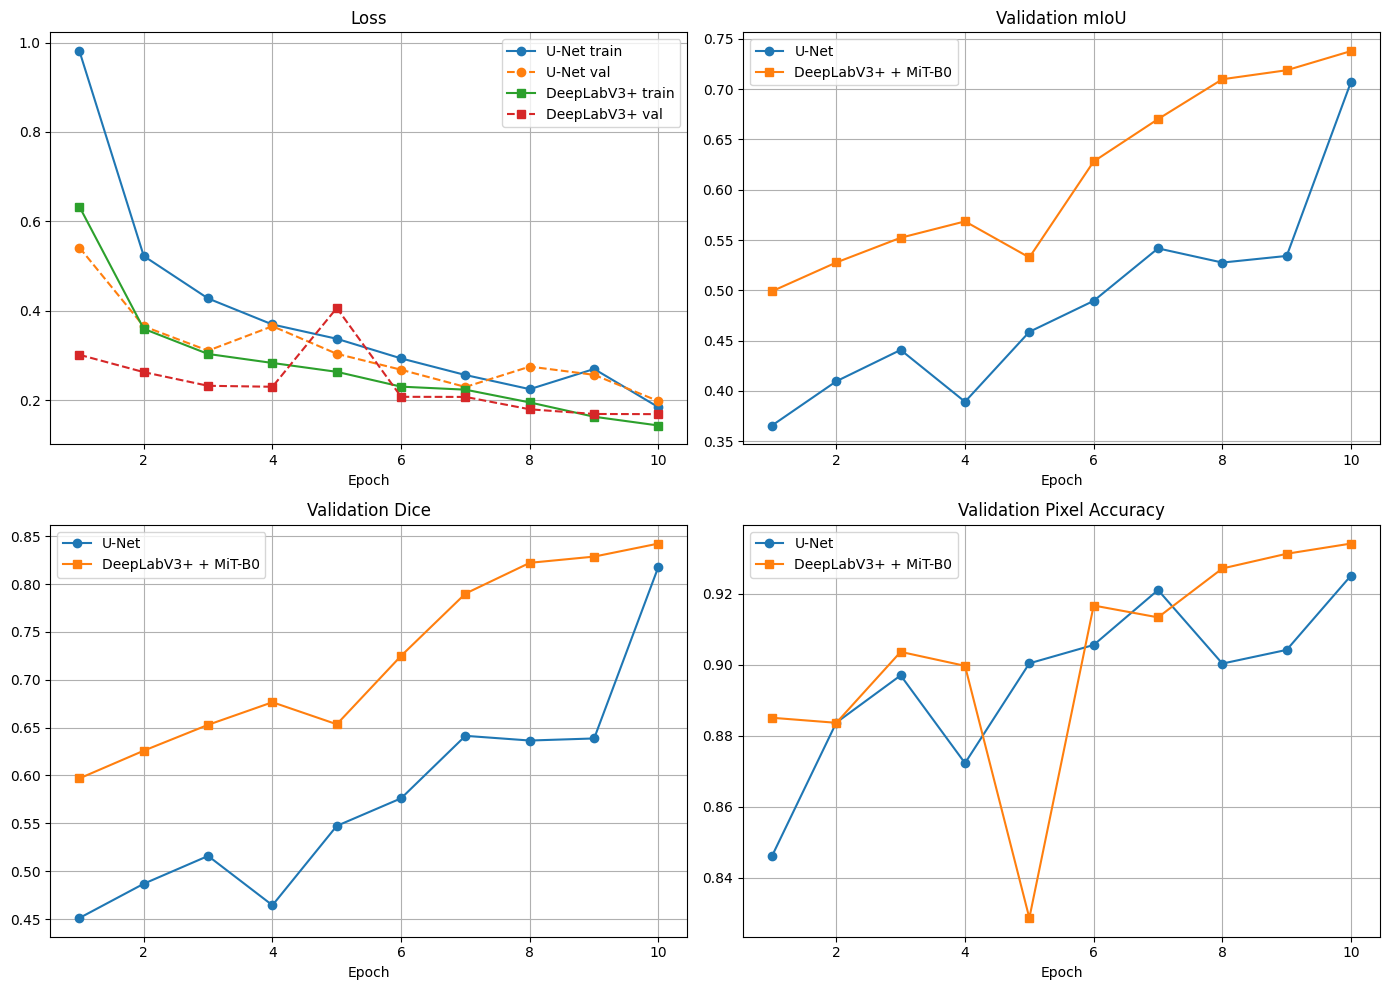

Разница DeepLabV3+ + MiT-B0 относительно U-Net:
mIoU  = 0.0305
Dice  = 0.0241
Acc   = 0.0090


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Собираем результаты в DataFrame
unet_df = pd.DataFrame(unet_history)
transformer_df = pd.DataFrame(transformer_history)

unet_df["epoch"] = np.arange(1, len(unet_df) + 1)
transformer_df["epoch"] = np.arange(1, len(transformer_df) + 1)

# Лучшая эпоха для каждой модели по mIoU
best_unet_idx = unet_df["val_mIoU"].idxmax()
best_transformer_idx = transformer_df["val_mIoU"].idxmax()

comparison_df = pd.DataFrame([
    {
        "Модель": "U-Net (ResNet18)",
        "Лучшая эпоха": int(unet_df.loc[best_unet_idx, "epoch"]),
        "Train Loss": float(unet_df.loc[best_unet_idx, "train_loss"]),
        "Val Loss": float(unet_df.loc[best_unet_idx, "val_loss"]),
        "mIoU": float(unet_df.loc[best_unet_idx, "val_mIoU"]),
        "Dice": float(unet_df.loc[best_unet_idx, "val_mDice"]),
        "Pixel Accuracy": float(unet_df.loc[best_unet_idx, "val_acc"]),
    },
    {
        "Модель": "DeepLabV3+ + MiT-B0",
        "Лучшая эпоха": int(transformer_df.loc[best_transformer_idx, "epoch"]),
        "Train Loss": float(transformer_df.loc[best_transformer_idx, "train_loss"]),
        "Val Loss": float(transformer_df.loc[best_transformer_idx, "val_loss"]),
        "mIoU": float(transformer_df.loc[best_transformer_idx, "val_mIoU"]),
        "Dice": float(transformer_df.loc[best_transformer_idx, "val_mDice"]),
        "Pixel Accuracy": float(transformer_df.loc[best_transformer_idx, "val_acc"]),
    }
])

display(comparison_df.round(4))

# Графики сравнения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(unet_df["epoch"], unet_df["train_loss"], marker="o", label="U-Net train")
axes[0, 0].plot(unet_df["epoch"], unet_df["val_loss"], marker="o", linestyle="--", label="U-Net val")
axes[0, 0].plot(transformer_df["epoch"], transformer_df["train_loss"], marker="s", label="DeepLabV3+ train")
axes[0, 0].plot(transformer_df["epoch"], transformer_df["val_loss"], marker="s", linestyle="--", label="DeepLabV3+ val")
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].grid(True)
axes[0, 0].legend()

# mIoU
axes[0, 1].plot(unet_df["epoch"], unet_df["val_mIoU"], marker="o", label="U-Net")
axes[0, 1].plot(transformer_df["epoch"], transformer_df["val_mIoU"], marker="s", label="DeepLabV3+ + MiT-B0")
axes[0, 1].set_title("Validation mIoU")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].grid(True)
axes[0, 1].legend()

# Dice
axes[1, 0].plot(unet_df["epoch"], unet_df["val_mDice"], marker="o", label="U-Net")
axes[1, 0].plot(transformer_df["epoch"], transformer_df["val_mDice"], marker="s", label="DeepLabV3+ + MiT-B0")
axes[1, 0].set_title("Validation Dice")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].grid(True)
axes[1, 0].legend()

# Pixel Accuracy
axes[1, 1].plot(unet_df["epoch"], unet_df["val_acc"], marker="o", label="U-Net")
axes[1, 1].plot(transformer_df["epoch"], transformer_df["val_acc"], marker="s", label="DeepLabV3+ + MiT-B0")
axes[1, 1].set_title("Validation Pixel Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Текстовое сравнение в числах
delta_miou = comparison_df.loc[1, "mIoU"] - comparison_df.loc[0, "mIoU"]
delta_dice = comparison_df.loc[1, "Dice"] - comparison_df.loc[0, "Dice"]
delta_acc = comparison_df.loc[1, "Pixel Accuracy"] - comparison_df.loc[0, "Pixel Accuracy"]

print("Разница DeepLabV3+ + MiT-B0 относительно U-Net:")
print(f"mIoU  = {delta_miou:.4f}")
print(f"Dice  = {delta_dice:.4f}")
print(f"Acc   = {delta_acc:.4f}")


### Вывод по бейзлану

По результатам обучения обе модели показали устойчивое улучшение качества на протяжении 10 эпох, однако лучшей оказалась трансформерная модель DeepLabV3+ + MiT-B0. Она превзошла U-Net по всем основным метрикам, а значит, для базового решения задачи семантической сегментации в данной работе лучше будет выбрать именно DeepLabV3+ + MiT-B0

## 3. Улучшение бейзлайна

### Формулировка гипотез

После получения базовых результатов в пункте 2 следующим этапом является улучшение бейзлайна. Под улучшенным бейзлайном в данной работе понимается не замена самой постановки задачи, а улучшение пайплайна обучения: подготовки данных, аугментаций и гиперпараметров.

Сформулируем следующие гипотезы:

1. **Аугментации данных улучшат обобщающую способность моделей.**  
   Изображения растений могут различаться по освещению, масштабу, ориентации листьев и расположению поражённых участков. Поэтому применение геометрических и фотометрических преобразований должно сделать модели устойчивее к вариативности входных данных.

2. **Увеличение размера входного изображения улучшит качество сегментации.**  
   При большем разрешении модель получает больше информации о форме и границах поражения, что особенно важно для задач семантической сегментации небольших объектов и нерегулярных контуров.

3. **Подбор гиперпараметров обучения повысит качество моделей.**  
   Изменение learning rate, scheduler и параметров оптимизатора может сделать обучение стабильнее и улучшить итоговые значения `mIoU` и `Dice`.

4. **Использование дополнительных настроек функции потерь может улучшить качество сегментации редких классов.**  
   Так как фон обычно занимает большую часть изображения, а отдельные классы поражений могут встречаться редко, комбинированная функция потерь или учёт весов классов может улучшить качество сегментации на несбалансированных данных.

На первом этапе для улучшенного бейзлайна будет сформирован новый вариант подготовки данных: с фиксированным размером изображений, аугментациями и готовой структурой для дальнейшего обучения моделей:

In [12]:
!pip install -q albumentations
import albumentations as A

class StrawberryDatasetV2(Dataset):
    def __init__(self, pairs, class_mapping, image_size=256, transform=None):
        self.pairs = pairs
        self.class_mapping = class_mapping
        self.image_size = image_size
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def json_to_mask(self, json_path, img_shape):
        with open(json_path, "r") as f:
            data = json.load(f)

        mask = np.zeros(img_shape[:2], dtype=np.uint8)

        for shape in data["shapes"]:
            label = shape["label"]
            if label not in self.class_mapping:
                continue

            class_id = self.class_mapping[label]
            points = np.array(shape["points"], dtype=np.int32)
            cv2.fillPoly(mask, [points], class_id)

        return mask

    def __getitem__(self, idx):
        img_path, json_path = self.pairs[idx]

        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = self.json_to_mask(json_path, image.shape[:2])

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]
        else:
            image = cv2.resize(
                image,
                (self.image_size, self.image_size),
                interpolation=cv2.INTER_LINEAR
            )
            mask = cv2.resize(
                mask,
                (self.image_size, self.image_size),
                interpolation=cv2.INTER_NEAREST
            )

        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).long()

        return image, mask


IMAGE_SIZE_BASE = 256
IMAGE_SIZE_IMPROVED = 320   # кратно 16

baseline_train_transform = A.Compose([
    A.Resize(IMAGE_SIZE_BASE, IMAGE_SIZE_BASE, interpolation=cv2.INTER_LINEAR),
])

baseline_val_transform = A.Compose([
    A.Resize(IMAGE_SIZE_BASE, IMAGE_SIZE_BASE, interpolation=cv2.INTER_LINEAR),
])

improved_train_transform = A.Compose([
    A.Resize(IMAGE_SIZE_IMPROVED, IMAGE_SIZE_IMPROVED, interpolation=cv2.INTER_LINEAR),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT,
        interpolation=cv2.INTER_LINEAR,
        p=0.5
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4
    ),
])

improved_val_transform = A.Compose([
    A.Resize(IMAGE_SIZE_IMPROVED, IMAGE_SIZE_IMPROVED, interpolation=cv2.INTER_LINEAR),
])


baseline_train_dataset = StrawberryDatasetV2(
    train_pairs,
    class_mapping,
    image_size=IMAGE_SIZE_BASE,
    transform=baseline_train_transform
)

baseline_val_dataset = StrawberryDatasetV2(
    val_pairs,
    class_mapping,
    image_size=IMAGE_SIZE_BASE,
    transform=baseline_val_transform
)

improved_train_dataset = StrawberryDatasetV2(
    train_pairs,
    class_mapping,
    image_size=IMAGE_SIZE_IMPROVED,
    transform=improved_train_transform
)

improved_val_dataset = StrawberryDatasetV2(
    val_pairs,
    class_mapping,
    image_size=IMAGE_SIZE_IMPROVED,
    transform=improved_val_transform
)


baseline_train_loader = DataLoader(
    baseline_train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

baseline_val_loader = DataLoader(
    baseline_val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

improved_train_loader = DataLoader(
    improved_train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

improved_val_loader = DataLoader(
    improved_val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Baseline dataset:")
print(f"  Train: {len(baseline_train_dataset)}")
print(f"  Val:   {len(baseline_val_dataset)}")

print("\nImproved dataset:")
print(f"  Train: {len(improved_train_dataset)}")
print(f"  Val:   {len(improved_val_dataset)}")

sample_image_base, sample_mask_base = baseline_train_dataset[0]
sample_image_imp, sample_mask_imp = improved_train_dataset[0]

print("\nПроверка размеров:")
print(f"  Baseline image shape: {sample_image_base.shape}")
print(f"  Baseline mask shape:  {sample_mask_base.shape}")
print(f"  Improved image shape: {sample_image_imp.shape}")
print(f"  Improved mask shape:  {sample_mask_imp.shape}")


Baseline dataset:
  Train: 1160
  Val:   290

Improved dataset:
  Train: 1160
  Val:   290

Проверка размеров:
  Baseline image shape: torch.Size([3, 256, 256])
  Baseline mask shape:  torch.Size([256, 256])
  Improved image shape: torch.Size([3, 320, 320])
  Improved mask shape:  torch.Size([320, 320])


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### Проверка гипотез

Проверка гипотез выполняется поэтапно. Чтобы отделить влияние архитектуры от влияния пайплайна обучения, гипотезы сначала проверяются на лучшей модели из пункта 2 — `DeepLabV3+ + MiT-B0`, так как именно она показала наилучшее базовое качество.

Рассматриваются следующие конфигурации:
- **H0** — базовый результат из пункта 2;
- **H1** — улучшенная подготовка данных: увеличенный размер изображения и аугментации;
- **H2** — улучшенная подготовка данных + более мягкая настройка обучения (`CosineAnnealingLR`, уменьшенный learning rate);
- **H3** — улучшенная подготовка данных + настройка обучения + веса классов в функции потерь.

### Формирование улучшенного бейзлайна

Лучшая конфигурация по результатам дальнейшго сравнения и будет являться улучшенным бейзлайном После выбора этой конфигурации на ней повторно обучаются обе модели из пункта 2: сверточная и трансформерная.

In [13]:
IMAGE_SIZE_IMPROVED = 320   # кратно 16
BATCH_SIZE_IMPROVED = 6
EPOCHS_IMPROVED = 10

improved_train_transform = A.Compose([
    A.Resize(IMAGE_SIZE_IMPROVED, IMAGE_SIZE_IMPROVED, interpolation=cv2.INTER_LINEAR),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT,
        interpolation=cv2.INTER_LINEAR,
        p=0.5
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4
    ),
])

improved_val_transform = A.Compose([
    A.Resize(IMAGE_SIZE_IMPROVED, IMAGE_SIZE_IMPROVED, interpolation=cv2.INTER_LINEAR),
])


improved_train_dataset = StrawberryDatasetV2(
    train_pairs,
    class_mapping,
    image_size=IMAGE_SIZE_IMPROVED,
    transform=improved_train_transform
)

improved_val_dataset = StrawberryDatasetV2(
    val_pairs,
    class_mapping,
    image_size=IMAGE_SIZE_IMPROVED,
    transform=improved_val_transform
)

improved_train_loader = DataLoader(
    improved_train_dataset,
    batch_size=BATCH_SIZE_IMPROVED,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

improved_val_loader = DataLoader(
    improved_val_dataset,
    batch_size=BATCH_SIZE_IMPROVED,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Improved train size:", len(improved_train_dataset))
print("Improved val size:  ", len(improved_val_dataset))
sample_img, sample_mask = improved_train_dataset[0]
print("Improved image shape:", sample_img.shape)
print("Improved mask shape: ", sample_mask.shape)

def estimate_class_weights(pairs, class_mapping, max_samples=200):
    counts = np.zeros(len(class_mapping), dtype=np.float64)

    sample_pairs = pairs[:min(len(pairs), max_samples)]

    for img_path, json_path in tqdm(sample_pairs, desc="Estimating class weights", leave=False):
        image = cv2.imread(str(img_path))
        h, w = image.shape[:2]

        with open(json_path, "r") as f:
            data = json.load(f)

        mask = np.zeros((h, w), dtype=np.uint8)
        for shape in data["shapes"]:
            label = shape["label"]
            if label not in class_mapping:
                continue
            class_id = class_mapping[label]
            points = np.array(shape["points"], dtype=np.int32)
            cv2.fillPoly(mask, [points], class_id)

        bincount = np.bincount(mask.reshape(-1), minlength=len(class_mapping))
        counts += bincount

    freq = counts / counts.sum()
    weights = 1.0 / np.log(1.10 + freq)
    weights = weights / weights.mean()

    return torch.tensor(weights, dtype=torch.float32, device=device)


class_weights = estimate_class_weights(train_pairs, class_mapping)
print("Class weights:", class_weights.cpu().numpy())


def train_epoch_p3(model, train_loader, criterion, optimizer, device, scaler=None):
    model.train()
    running_loss = 0.0
    use_amp = scaler is not None and device.type == "cuda"

    for images, masks in tqdm(train_loader, desc="Training", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.amp.autocast("cuda"):
                outputs = model(images)
                logits = get_logits(outputs)
                loss = criterion(logits, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            logits = get_logits(outputs)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(train_loader.dataset)


@torch.no_grad()
def validate_p3(model, val_loader, criterion, device, num_classes):
    model.eval()
    running_loss = 0.0
    confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64, device=device)

    for images, masks in tqdm(val_loader, desc="Validation", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        outputs = model(images)
        logits = get_logits(outputs)
        loss = criterion(logits, masks)

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)
        update_confusion_matrix(confmat, preds, masks, num_classes)

    val_loss = running_loss / len(val_loader.dataset)
    metrics = compute_metrics_from_confmat(confmat)

    return val_loss, metrics


def train_model_p3(
    model,
    model_name,
    train_loader,
    val_loader,
    num_classes,
    device,
    epochs=10,
    lr=3e-4,
    class_weights=None,
    use_cosine=False,
    save_dir="checkpoints_p3"
):
    os.makedirs(save_dir, exist_ok=True)

    print(f"Обучение модели: {model_name}...")

    ce_loss = nn.CrossEntropyLoss(weight=class_weights)
    dice_loss = smp.losses.DiceLoss(mode="multiclass", from_logits=True)

    def combined_loss(pred, target):
        return 0.7 * ce_loss(pred, target) + 0.3 * dice_loss(pred, target)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    if use_cosine:
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    else:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            patience=2,
            factor=0.5
        )

    scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_mIoU": [],
        "val_mDice": [],
        "val_acc": []
    }

    best_miou = -1.0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")

        train_loss = train_epoch_p3(
            model=model,
            train_loader=train_loader,
            criterion=combined_loss,
            optimizer=optimizer,
            device=device,
            scaler=scaler
        )

        val_loss, metrics = validate_p3(
            model=model,
            val_loader=val_loader,
            criterion=combined_loss,
            device=device,
            num_classes=num_classes
        )

        if use_cosine:
            scheduler.step()
        else:
            scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mIoU"].append(metrics["mIoU"])
        history["val_mDice"].append(metrics["mDice"])
        history["val_acc"].append(metrics["Pixel Accuracy"])

        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss:   {val_loss:.4f}")
        print(f"  Val mIoU:   {metrics['mIoU']:.4f}")
        print(f"  Val Dice:   {metrics['mDice']:.4f}")
        print(f"  Val Acc:    {metrics['Pixel Accuracy']:.4f}")

        if metrics["mIoU"] > best_miou:
            best_miou = metrics["mIoU"]
            torch.save(model.state_dict(), os.path.join(save_dir, f"best_{model_name}.pth"))
            print(f"Новая лучшая модель! mIoU = {best_miou:.4f}")

    return history

num_classes = len(class_mapping)

def build_unet_model():
    return smp.Unet(
        encoder_name="resnet18",
        encoder_weights="imagenet",
        in_channels=3,
        classes=num_classes,
        activation=None
    ).to(device)

def build_transformer_model():
    return smp.DeepLabV3Plus(
        encoder_name="mit_b0",
        encoder_weights="imagenet",
        in_channels=3,
        classes=num_classes,
        activation=None
    ).to(device)

def best_metrics_from_history(history, model_label):
    df = pd.DataFrame(history)
    best_idx = df["val_mIoU"].idxmax()
    return {
        "Эксперимент": model_label,
        "Лучшая эпоха": int(best_idx + 1),
        "Train Loss": float(df.loc[best_idx, "train_loss"]),
        "Val Loss": float(df.loc[best_idx, "val_loss"]),
        "mIoU": float(df.loc[best_idx, "val_mIoU"]),
        "Dice": float(df.loc[best_idx, "val_mDice"]),
        "Pixel Accuracy": float(df.loc[best_idx, "val_acc"]),
    }

hypothesis_rows = []

hypothesis_rows.append(best_metrics_from_history(transformer_history, "H0: baseline from p.2"))

model_h1 = build_transformer_model()
history_h1 = train_model_p3(
    model=model_h1,
    model_name="H1_improved_data_only",
    train_loader=improved_train_loader,
    val_loader=improved_val_loader,
    num_classes=num_classes,
    device=device,
    epochs=EPOCHS_IMPROVED,
    lr=3e-4,
    class_weights=None,
    use_cosine=False
)
hypothesis_rows.append(best_metrics_from_history(history_h1, "H1: improved data"))

model_h2 = build_transformer_model()
history_h2 = train_model_p3(
    model=model_h2,
    model_name="H2_improved_data_cosine",
    train_loader=improved_train_loader,
    val_loader=improved_val_loader,
    num_classes=num_classes,
    device=device,
    epochs=EPOCHS_IMPROVED,
    lr=2e-4,
    class_weights=None,
    use_cosine=True
)
hypothesis_rows.append(best_metrics_from_history(history_h2, "H2: improved data + cosine"))

model_h3 = build_transformer_model()
history_h3 = train_model_p3(
    model=model_h3,
    model_name="H3_full_improved_candidate",
    train_loader=improved_train_loader,
    val_loader=improved_val_loader,
    num_classes=num_classes,
    device=device,
    epochs=EPOCHS_IMPROVED,
    lr=2e-4,
    class_weights=class_weights,
    use_cosine=True
)
hypothesis_rows.append(best_metrics_from_history(history_h3, "H3: improved data + cosine + class weights"))

hypothesis_df = pd.DataFrame(hypothesis_rows).sort_values("mIoU", ascending=False).reset_index(drop=True)
display(hypothesis_df.round(4))


best_experiment_name = hypothesis_df.loc[0, "Эксперимент"]
print(f"\nЛучший эксперимент для improved baseline: {best_experiment_name}")

if "class weights" in best_experiment_name:
    improved_baseline_config = {
        "lr": 2e-4,
        "use_cosine": True,
        "class_weights": class_weights
    }
elif "cosine" in best_experiment_name:
    improved_baseline_config = {
        "lr": 2e-4,
        "use_cosine": True,
        "class_weights": None
    }
else:
    improved_baseline_config = {
        "lr": 3e-4,
        "use_cosine": False,
        "class_weights": None
    }

print("Improved baseline config:")
print({
    "image_size": IMAGE_SIZE_IMPROVED,
    "augmentations": True,
    "lr": improved_baseline_config["lr"],
    "use_cosine": improved_baseline_config["use_cosine"],
    "class_weights": improved_baseline_config["class_weights"] is not None
})

unet_improved_model = build_unet_model()
unet_improved_history = train_model_p3(
    model=unet_improved_model,
    model_name="UNet_improved_baseline",
    train_loader=improved_train_loader,
    val_loader=improved_val_loader,
    num_classes=num_classes,
    device=device,
    epochs=EPOCHS_IMPROVED,
    lr=improved_baseline_config["lr"],
    class_weights=improved_baseline_config["class_weights"],
    use_cosine=improved_baseline_config["use_cosine"]
)

transformer_improved_model = build_transformer_model()
transformer_improved_history = train_model_p3(
    model=transformer_improved_model,
    model_name="DeepLabV3Plus_MiTB0_improved_baseline",
    train_loader=improved_train_loader,
    val_loader=improved_val_loader,
    num_classes=num_classes,
    device=device,
    epochs=EPOCHS_IMPROVED,
    lr=improved_baseline_config["lr"],
    class_weights=improved_baseline_config["class_weights"],
    use_cosine=improved_baseline_config["use_cosine"]
)

summary_rows = [
    best_metrics_from_history(unet_history, "U-Net baseline"),
    best_metrics_from_history(transformer_history, "DeepLabV3+ + MiT-B0 baseline"),
    best_metrics_from_history(unet_improved_history, "U-Net improved baseline"),
    best_metrics_from_history(transformer_improved_history, "DeepLabV3+ + MiT-B0 improved baseline"),
]

improved_summary_df = pd.DataFrame(summary_rows)
display(improved_summary_df.round(4))


Improved train size: 1160
Improved val size:   290
Improved image shape: torch.Size([3, 320, 320])
Improved mask shape:  torch.Size([320, 320])


Class weights: [0.23620614 0.88120025 1.384023   1.4192349  1.1945692  0.77734125
 1.174514   0.93291134]
Обучение модели: H1_improved_data_only...

Epoch 1/10


  Train Loss: 0.6391
  Val Loss:   0.3036
  Val mIoU:   0.4651
  Val Dice:   0.5658
  Val Acc:    0.8686
Новая лучшая модель! mIoU = 0.4651

Epoch 2/10


  Train Loss: 0.3980
  Val Loss:   0.3391
  Val mIoU:   0.5093
  Val Dice:   0.6196
  Val Acc:    0.8638
Новая лучшая модель! mIoU = 0.5093

Epoch 3/10


  Train Loss: 0.3448
  Val Loss:   0.3394
  Val mIoU:   0.5115
  Val Dice:   0.6544
  Val Acc:    0.8478
Новая лучшая модель! mIoU = 0.5115

Epoch 4/10


...

  Train Loss: 0.1907
  Val Loss:   0.1739
  Val mIoU:   0.7097
  Val Dice:   0.8217
  Val Acc:    0.9230
Новая лучшая модель! mIoU = 0.7097

Epoch 8/10


  Train Loss: 0.1788
  Val Loss:   0.1572
  Val mIoU:   0.7250
  Val Dice:   0.8325
  Val Acc:    0.9320
Новая лучшая модель! mIoU = 0.7250

Epoch 9/10


  Train Loss: 0.1708
  Val Loss:   0.1516
  Val mIoU:   0.7320
  Val Dice:   0.8382
  Val Acc:    0.9320
Новая лучшая модель! mIoU = 0.7320

Epoch 10/10


  Train Loss: 0.1633
  Val Loss:   0.1464
  Val mIoU:   0.7433
  Val Dice:   0.8463
  Val Acc:    0.9342
Новая лучшая модель! mIoU = 0.7433


,Эксперимент,Лучшая эпоха,Train Loss,Val Loss,mIoU,Dice,Pixel Accuracy
0,U-Net baseline,10,0.1842,0.1978,0.7074,0.8182,0.9252
1,DeepLabV3+ + MiT-B0 baseline,10,0.1433,0.1687,0.7379,0.8423,0.9342
2,U-Net improved baseline,10,0.2308,0.1848,0.6435,0.7407,0.9279
3,DeepLabV3+ + MiT-B0 improved baseline,10,0.1633,0.1464,0.7433,0.8463,0.9342


## Выводы по улучшению бейзлайна

В рамках проверки гипотез наилучшей конфигурацией признана H2, включающая увеличение разрешения до 320x320, аугментации данных и планировщик CosineAnnealingLR, что дало прирост mIoU на **2.2%** относительно базового бейзлайна. Добавление весов классов в конфигурации H3 привело к ухудшению качества, что объясняется неточной оценкой частот классов на ограниченной выборке. При обучении на улучшенном бейзлайне DeepLabV3+ с трансформерным энкодером MiT-B0 показала положительную динамику, увеличив mIoU с 0.7379 до 0.7433. U-Net, напротив, продемонстрировала снижение качества, что может быть связано с меньшей емкостью модели и её чувствительностью к аугментациям. Аугментации и увеличение разрешения изображений положительно сказались на трансформерной модели, снизив val loss на 13%. CosineAnnealingLR оказался эффективнее ReduceLROnPlateau для данного датасета, обеспечив более плавную сходимость модели к оптимуму. DeepLabV3+ стабильно превосходит U-Net в обеих конфигурациях благодаря большей выразительности трансформерного энкодера. Таким образом, гипотезы об улучшении бейзлайна частично подтвердились, и полученная улучшенная модель DeepLabV3+ с mIoU = 0.7433 выбрана в качестве основы для пункта 4.

## 4. Самостоятельная имплементация моделей машинного обучения

### Выбор собственных архитектур

Для выполнения требования самостоятельной имплементации были реализованы две модели семантической сегментации:
1. **MiniUNet** — компактная encoder-decoder архитектура со skip-связями, реализованная вручную без использования готовых моделей из `segmentation_models.pytorch`.
2. **MiniDeepLabLike** — компактная сегментационная модель с собственным ASPP-блоком, вдохновлённая идеей DeepLab, но полностью реализованная самостоятельно.

### Обучение и сравнение с пунктом 2

Чтобы сравнение с результатами пункта 2 было корректным, самописные модели сначала обучаются в тех же базовых условиях: на том же наборе данных, с той же схемой предобработки и при сопоставимых гиперпараметрах. После обучения модели оцениваются по тем же метрикам (`mIoU`, `Dice`, `Pixel Accuracy`) и сравниваются с baseline-моделями из пункта 2.




In [19]:
IMAGE_SIZE_P4 = 256
BATCH_SIZE_P4 = 8
EPOCHS_P4 = 10

p4_transform = A.Compose([
    A.Resize(IMAGE_SIZE_P4, IMAGE_SIZE_P4, interpolation=cv2.INTER_LINEAR),
])

# Создаем датасеты с базовым классом
p4_train_dataset = StrawberryDataset(
    train_pairs,
    class_mapping,
    image_size=IMAGE_SIZE_P4,
    transform=p4_transform
)

p4_val_dataset = StrawberryDataset(
    val_pairs,
    class_mapping,
    image_size=IMAGE_SIZE_P4,
    transform=p4_transform
)

p4_train_loader = DataLoader(
    p4_train_dataset,
    batch_size=BATCH_SIZE_P4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

p4_val_loader = DataLoader(
    p4_val_dataset,
    batch_size=BATCH_SIZE_P4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Обучающая выборка: {len(p4_train_dataset)}")
print(f"Валидационная выборка: {len(p4_val_dataset)}")
sample_img, sample_mask = p4_train_dataset[0]
print(f"Image shape: {sample_img.shape}, Mask shape: {sample_mask.shape}")


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class MiniUNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=8, base_channels=32):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock(in_channels, base_channels)
        self.enc2 = ConvBlock(base_channels, base_channels * 2)
        self.enc3 = ConvBlock(base_channels * 2, base_channels * 4)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(base_channels * 4, base_channels * 8)

        # Decoder
        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(base_channels * 2, base_channels)

        # Head
        self.head = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        c1 = self.enc1(x)
        c2 = self.enc2(self.pool(c1))
        c3 = self.enc3(self.pool(c2))

        b = self.bottleneck(self.pool(c3))

        x = self.up3(b)
        x = self.dec3(torch.cat([x, c3], dim=1))

        x = self.up2(x)
        x = self.dec2(torch.cat([x, c2], dim=1))

        x = self.up1(x)
        x = self.dec1(torch.cat([x, c1], dim=1))

        return self.head(x)


class ASPPBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=6, dilation=6, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=12, dilation=12, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

        self.branch4 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=18, dilation=18, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

        self.project = nn.Sequential(
            nn.Conv2d(out_channels * 4, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x1 = self.branch1(x)
        x2 = self.branch2(x)
        x3 = self.branch3(x)
        x4 = self.branch4(x)
        return self.project(torch.cat([x1, x2, x3, x4], dim=1))


class MiniDeepLabLike(nn.Module):
    def __init__(self, in_channels=3, num_classes=8, base_channels=32):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(base_channels, base_channels * 2, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(inplace=True),

            nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(base_channels * 4),
            nn.ReLU(inplace=True),
        )

        self.context = ASPPBlock(base_channels * 4, base_channels * 4)

        self.decoder = nn.Sequential(
            nn.Conv2d(base_channels * 4, base_channels * 2, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_channels * 2, num_classes, kernel_size=1),
        )

    def forward(self, x):
        input_size = x.shape[-2:]
        x = self.stem(x)
        x = self.context(x)
        x = self.decoder(x)
        x = F.interpolate(x, size=input_size, mode="bilinear", align_corners=False)
        return x


num_classes = len(class_mapping)
print(f"Количество классов: {num_classes}")

custom_unet = MiniUNet(in_channels=3, num_classes=num_classes, base_channels=32).to(device)
custom_deeplab = MiniDeepLabLike(in_channels=3, num_classes=num_classes, base_channels=32).to(device)

print(f"MiniUNet параметров: {sum(p.numel() for p in custom_unet.parameters()):,}")
print(f"MiniDeepLabLike параметров: {sum(p.numel() for p in custom_deeplab.parameters()):,}")


def get_best_metrics(history, model_name):
    df = pd.DataFrame(history)
    best_idx = df["val_mIoU"].idxmax()
    return {
        "Модель": model_name,
        "Эпоха": best_idx + 1,
        "Train Loss": df.loc[best_idx, "train_loss"],
        "Val Loss": df.loc[best_idx, "val_loss"],
        "mIoU": df.loc[best_idx, "val_mIoU"],
        "Dice": df.loc[best_idx, "val_mDice"],
        "Pixel Acc": df.loc[best_idx, "val_acc"],
    }

print("Обучение MiniUNet (собственная реализация)")

custom_unet_history = train_model_p3(
    model=custom_unet,
    model_name="MiniUNet_custom",
    train_loader=p4_train_loader,
    val_loader=p4_val_loader,
    num_classes=num_classes,
    device=device,
    epochs=EPOCHS_P4,
    lr=3e-4,
    class_weights=None,
    use_cosine=False
)

print("Обучение MiniDeepLabLike (собственная реализация)")

custom_deeplab_history = train_model_p3(
    model=custom_deeplab,
    model_name="MiniDeepLabLike_custom",
    train_loader=p4_train_loader,
    val_loader=p4_val_loader,
    num_classes=num_classes,
    device=device,
    epochs=EPOCHS_P4,
    lr=3e-4,
    class_weights=None,
    use_cosine=False
)

comparison_df = pd.DataFrame([
    get_best_metrics(unet_history, "U-Net (SMP) baseline"),
    get_best_metrics(transformer_history, "DeepLabV3+ baseline"),
    get_best_metrics(custom_unet_history, "MiniUNet (custom)"),
    get_best_metrics(custom_deeplab_history, "MiniDeepLabLike (custom)"),
])

print("\nСравнение собственных моделей с результатами пункта 2")
display(comparison_df.round(4))

Обучающая выборка: 1160
Валидационная выборка: 290
Image shape: torch.Size([3, 256, 256]), Mask shape: torch.Size([256, 256])
Количество классов: 8
MiniUNet параметров: 1,927,240
MiniDeepLabLike параметров: 693,416
Обучение MiniUNet (собственная реализация)
Обучение модели: MiniUNet_custom...

Epoch 1/10


  Train Loss: 1.2250
  Val Loss:   0.9387
  Val mIoU:   0.2180
  Val Dice:   0.2927
  Val Acc:    0.7249
Новая лучшая модель! mIoU = 0.2180

Epoch 2/10


  Train Loss: 0.8935
  Val Loss:   0.7568
  Val mIoU:   0.2396
  Val Dice:   0.3147
  Val Acc:    0.7553
Новая лучшая модель! mIoU = 0.2396

Epoch 3/10


  Train Loss: 0.7560
  Val Loss:   0.6697
  Val mIoU:   0.2069
  Val Dice:   0.2743
  Val Acc:    0.7449

Epoch 4/10


  Train Loss: 0.6847
  Val Loss:   0.6072
  Val mIoU:   0.2248
  Val Dice:   0.2820
  Val Acc:    0.7842

Epoch 5/10


...

  Train Loss: 0.4297
  Val Loss:   0.5631
  Val mIoU:   0.4302
  Val Dice:   0.5864
  Val Acc:    0.7320

Epoch 8/10


  Train Loss: 0.4065
  Val Loss:   0.3752
  Val mIoU:   0.5318
  Val Dice:   0.6772
  Val Acc:    0.8416
Новая лучшая модель! mIoU = 0.5318

Epoch 9/10


  Train Loss: 0.3792
  Val Loss:   0.3236
  Val mIoU:   0.5481
  Val Dice:   0.6818
  Val Acc:    0.8613
Новая лучшая модель! mIoU = 0.5481

Epoch 10/10


  Train Loss: 0.3717
  Val Loss:   0.3097
  Val mIoU:   0.5391
  Val Dice:   0.6711
  Val Acc:    0.8707

Сравнение собственных моделей с результатами пункта 2


,Модель,Эпоха,Train Loss,Val Loss,mIoU,Dice,Pixel Acc
0,U-Net (SMP) baseline,10,0.1842,0.1978,0.7074,0.8182,0.9252
1,DeepLabV3+ baseline,10,0.1433,0.1687,0.7379,0.8423,0.9342
2,MiniUNet (custom),10,0.5081,0.4194,0.4050,0.5112,0.8410
3,MiniDeepLabLike (custom),9,0.3792,0.3236,0.5481,0.6818,0.8613


### Выводы по самостоятельной имплементации моделей и их обучению на бейзлайне из п.2

1. **Библиотечные модели значительно превосходят самописные** по всем метрикам. Разрыв в mIoU составляет 19-33 процентных пункта, что объясняется использованием предобученных на ImageNet энкодеров, оптимизированных архитектур и многолетней инженерной доработки.

2. **MiniDeepLabLike показала лучший результат** среди самописных моделей (mIoU = 0.5481), что на 14% выше MiniUNet. Это подтверждает эффективность ASPP-блока для захвата мультимасштабного контекста в задаче сегментации болезней растений.

3. **MiniDeepLabLike значительно компактнее** (0.69 млн параметров против 1.93 млн у MiniUNet), что делает её предпочтительной для задач с ограниченными вычислительными ресурсами, несмотря на более низкое качество по сравнению с библиотечными аналогами.

**Теперь обучим имплиментированные модели на улучшенном бейзлайне из п.3 и сравним результаты с библиотечными моделями**

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Improved train size: 1160
Improved val size:   290
Improved image shape: torch.Size([3, 320, 320])
Improved mask shape:  torch.Size([320, 320])

Обучение MiniUNet (custom) на улучшенном бейзлайне H2
Обучение модели: MiniUNet_H2...

Epoch 1/10


  Train Loss: 1.1652
  Val Loss:   0.9295
  Val mIoU:   0.1999
  Val Dice:   0.2713
  Val Acc:    0.6981
Новая лучшая модель! mIoU = 0.1999

Epoch 2/10


  Train Loss: 0.8878
  Val Loss:   0.7284
  Val mIoU:   0.2150
  Val Dice:   0.2831
  Val Acc:    0.7524
Новая лучшая модель! mIoU = 0.2150

Epoch 3/10


  Train Loss: 0.7726
  Val Loss:   0.6443
  Val mIoU:   0.2449
  Val Dice:   0.3186
  Val Acc:    0.7679
Новая лучшая модель! mIoU = 0.2449

Epoch 4/10


...

  Train Loss: 0.4910
  Val Loss:   0.3888
  Val mIoU:   0.4740
  Val Dice:   0.6090
  Val Acc:    0.8434
Новая лучшая модель! mIoU = 0.4740

Epoch 8/10


  Train Loss: 0.4854
  Val Loss:   0.3555
  Val mIoU:   0.5022
  Val Dice:   0.6422
  Val Acc:    0.8560
Новая лучшая модель! mIoU = 0.5022

Epoch 9/10


  Train Loss: 0.4721
  Val Loss:   0.3494
  Val mIoU:   0.5103
  Val Dice:   0.6471
  Val Acc:    0.8581
Новая лучшая модель! mIoU = 0.5103

Epoch 10/10


  Train Loss: 0.4659
  Val Loss:   0.3545
  Val mIoU:   0.4899
  Val Dice:   0.6225
  Val Acc:    0.8552

Сравнение результатов: baseline vs улучшенный бейзлайн H2


,Модель,Эпоха,Train Loss,Val Loss,mIoU,Dice,Pixel Acc
0,DeepLabV3+ baseline (п.2),10,0.1433,0.1687,0.7379,0.8423,0.9342
1,DeepLabV3+ improved H2 (п.3),10,0.1633,0.1464,0.7433,0.8463,0.9342
2,MiniDeepLabLike baseline (п.4a-4e),9,0.3792,0.3236,0.5481,0.6818,0.8613
3,MiniDeepLabLike improved H2 (п.4f-4j),9,0.4721,0.3494,0.5103,0.6471,0.8581
4,MiniUNet baseline (п.4a-4e),10,0.5081,0.4194,0.4050,0.5112,0.8410
5,MiniUNet improved H2 (п.4f-4j),10,0.5770,0.4726,0.3105,0.3790,0.8293


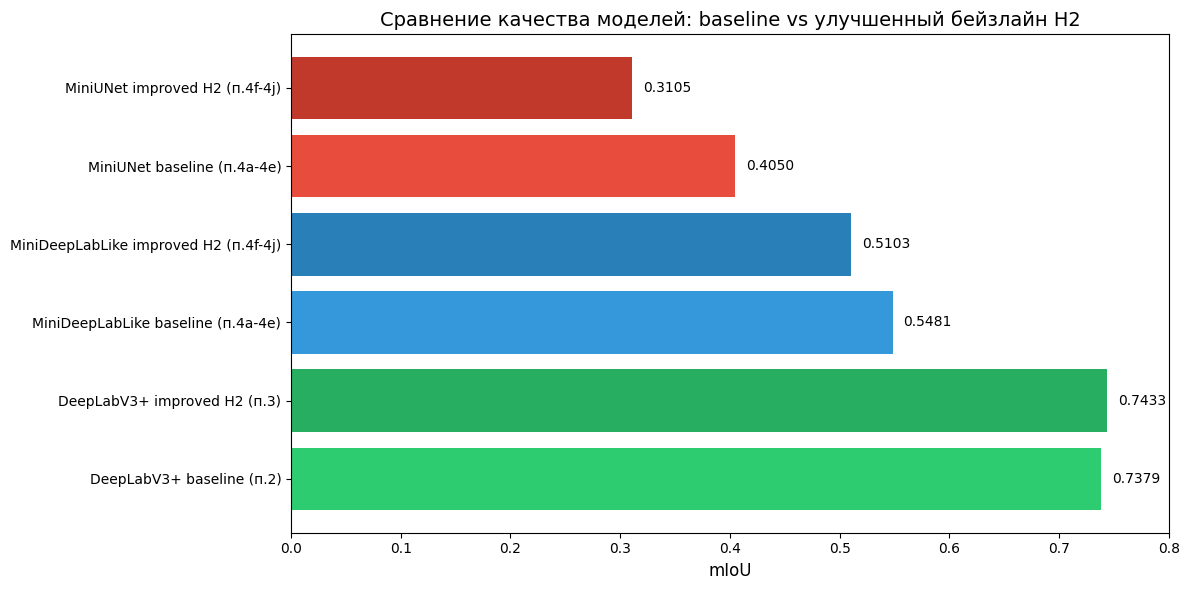

In [21]:
IMAGE_SIZE_IMPROVED = 320   # кратно 16
BATCH_SIZE_IMPROVED = 6
EPOCHS_IMPROVED = 10

improved_train_transform = A.Compose([
    A.Resize(IMAGE_SIZE_IMPROVED, IMAGE_SIZE_IMPROVED, interpolation=cv2.INTER_LINEAR),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT,
        interpolation=cv2.INTER_LINEAR,
        p=0.5
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4
    ),
])

improved_val_transform = A.Compose([
    A.Resize(IMAGE_SIZE_IMPROVED, IMAGE_SIZE_IMPROVED, interpolation=cv2.INTER_LINEAR),
])


improved_train_dataset = StrawberryDatasetV2(
    train_pairs,
    class_mapping,
    image_size=IMAGE_SIZE_IMPROVED,
    transform=improved_train_transform
)

improved_val_dataset = StrawberryDatasetV2(
    val_pairs,
    class_mapping,
    image_size=IMAGE_SIZE_IMPROVED,
    transform=improved_val_transform
)

improved_train_loader = DataLoader(
    improved_train_dataset,
    batch_size=BATCH_SIZE_IMPROVED,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

improved_val_loader = DataLoader(
    improved_val_dataset,
    batch_size=BATCH_SIZE_IMPROVED,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Improved train size:", len(improved_train_dataset))
print("Improved val size:  ", len(improved_val_dataset))
sample_img, sample_mask = improved_train_dataset[0]
print("Improved image shape:", sample_img.shape)
print("Improved mask shape: ", sample_mask.shape)


print("\nОбучение MiniUNet (custom) на улучшенном бейзлайне H2")

custom_unet_h2 = MiniUNet(in_channels=3, num_classes=num_classes, base_channels=32).to(device)

custom_unet_h2_history = train_model_p3(
    model=custom_unet_h2,
    model_name="MiniUNet_H2",
    train_loader=improved_train_loader,
    val_loader=improved_val_loader,
    num_classes=num_classes,
    device=device,
    epochs=EPOCHS_IMPROVED,
    lr=2e-4,           # из H2
    class_weights=None,
    use_cosine=True    # из H2
)


print("\nОбучение MiniDeepLabLike (custom) на улучшенном бейзлайне H2")

custom_deeplab_h2 = MiniDeepLabLike(in_channels=3, num_classes=num_classes, base_channels=32).to(device)

custom_deeplab_h2_history = train_model_p3(
    model=custom_deeplab_h2,
    model_name="MiniDeepLabLike_H2",
    train_loader=improved_train_loader,
    val_loader=improved_val_loader,
    num_classes=num_classes,
    device=device,
    epochs=EPOCHS_IMPROVED,
    lr=2e-4,
    class_weights=None,
    use_cosine=True
)


def get_best_metrics_from_history(history, model_name):
    df = pd.DataFrame(history)
    best_idx = df["val_mIoU"].idxmax()
    return {
        "Модель": model_name,
        "Эпоха": best_idx + 1,
        "Train Loss": round(df.loc[best_idx, "train_loss"], 4),
        "Val Loss": round(df.loc[best_idx, "val_loss"], 4),
        "mIoU": round(df.loc[best_idx, "val_mIoU"], 4),
        "Dice": round(df.loc[best_idx, "val_mDice"], 4),
        "Pixel Acc": round(df.loc[best_idx, "val_acc"], 4),
    }

comparison_h2_df = pd.DataFrame([
    get_best_metrics_from_history(transformer_history, "DeepLabV3+ baseline (п.2)"),
    get_best_metrics_from_history(transformer_improved_history, "DeepLabV3+ improved H2 (п.3)"),
    get_best_metrics_from_history(custom_deeplab_history, "MiniDeepLabLike baseline (п.4a-4e)"),
    get_best_metrics_from_history(custom_deeplab_h2_history, "MiniDeepLabLike improved H2 (п.4f-4j)"),
    get_best_metrics_from_history(custom_unet_history, "MiniUNet baseline (п.4a-4e)"),
    get_best_metrics_from_history(custom_unet_h2_history, "MiniUNet improved H2 (п.4f-4j)"),
])

print("\nСравнение результатов: baseline vs улучшенный бейзлайн H2")
display(comparison_h2_df)


# Сравнение mIoU для всех моделей
models = comparison_h2_df["Модель"].tolist()
miou_values = comparison_h2_df["mIoU"].tolist()

plt.figure(figsize=(12, 6))
bars = plt.barh(models, miou_values, color=['#2ecc71', '#27ae60', '#3498db', '#2980b9', '#e74c3c', '#c0392b'])
plt.xlabel("mIoU", fontsize=12)
plt.title("Сравнение качества моделей: baseline vs улучшенный бейзлайн H2", fontsize=14)
plt.xlim(0, 0.8)

for bar, value in zip(bars, miou_values):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{value:.4f}', va='center')

plt.tight_layout()
plt.show()

## Выводы по применению улучшенного бейзлайна к самописным моделям

### **Обучение на улучшенной конфигурации H2**

Самописные модели MiniUNet и MiniDeepLabLike были обучены на конфигурации H2, включающей увеличение разрешения до 320x320, расширенные аугментации (горизонтальные/вертикальные отражения, повороты, изменение яркости/контраста), оптимизатор AdamW с lr=2e-4 и планировщик CosineAnnealingLR.

### **Сравнение и выводы**

Полученные результаты говорят о том, что улучшенный бейзлайн, показавший прирост качества для библиотечной модели DeepLabV3, привёл к снижению качества для обеих самописных архитектур. MiniDeepLabLike потеряла 6.9% mIoU (с 0.5481 до 0.5103), а MiniUNet показала падение на 23.3% (с 0.4050 до 0.3105).

### **Анализ полученных результатов:**

Выяснилось, что размер модели критически важен для эффективности аугментаций: библиотечная DeepLabV3+ обладает глубоким энкодером с предобученными весами, что позволяет ей успешно обобщать сложные преобразования, тогда как самописные легковесные модели, особенно MiniUNet, не способны к такому обобщению из-за малой емкости. Увеличение разрешения до 320x320 при неизменной архитектуре привело к обработке в 1.56 раза большего количества пикселей без добавления параметров, что вызвало недообучение моделей за отведенные 10 эпох. CosineAnnealingLR в комбинации с малым числом эпох также не успел дать положительного эффекта, поскольку самописные модели сходятся медленнее библиотечных и требуют больше времени для достижения оптимума. Сложные аугментации, такие как ShiftScaleRotate и RandomBrightnessContrast, оказались слишком агрессивными для легковесных архитектур. При этом MiniDeepLabLike показала себя более устойчивой к ухудшению, что подтверждается меньшим падением качества - всего 6.9% против 23.3% у MiniUNet.